# ch195 — Sparse Matrices and Efficient Representations

> **Prerequisites:** ch151 (Introduction to Matrices), ch154 (Matrix Multiplication), ch160 (Systems of Linear Equations), ch192 (Rank, Nullity)
> **You will learn:**
> - What makes a matrix sparse and why it matters computationally
> - COO, CSR, and CSC storage formats
> - Sparse matrix-vector multiplication from scratch
> - How sparsity arises in real applications (graphs, finite elements, NLP)
> - The tradeoff between storage format and operation efficiency
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

A **sparse matrix** is one where most entries are zero. The standard dense representation wastes both memory and computation on these zeros. For a $10^6 \times 10^6$ matrix with 10 non-zeros per row, dense storage requires $10^{12}$ floats (8 TB); sparse storage requires only $10^7$ floats (80 MB).

Sparsity arises wherever structure limits interaction:
- **Graphs**: adjacency matrix of a sparse graph
- **Finite element methods**: each element touches only nearby elements
- **NLP**: term-document matrix (most words don't appear in most documents)
- **Neural networks**: convolutional layers have sparse connectivity patterns

Common misconception: sparse formats are not always faster. For dense operations (e.g., matrix-matrix product of two sparse matrices producing a dense result), dense storage can win.

## 2. Intuition & Mental Models

**Think of a sparse matrix as a list of non-zero entries**, not a grid. Instead of storing 1 million zeros, store 10,000 (row, col, value) triples.

**Three formats, each optimized for different operations:**
- **COO (Coordinate)**: `(rows, cols, vals)` — easy to construct, slow for arithmetic
- **CSR (Compressed Sparse Row)**: row pointers + column indices — fast row access and matrix-vector product
- **CSC (Compressed Sparse Column)**: column pointers + row indices — fast column access and transpose operations

**Recall from ch154 (Matrix Multiplication):** dense $A\mathbf{x}$ takes $O(mn)$ operations. Sparse $A\mathbf{x}$ takes $O(nnz)$ where $nnz$ = number of non-zeros. If $nnz \ll mn$, this is a massive speedup.

## 3. Visualization

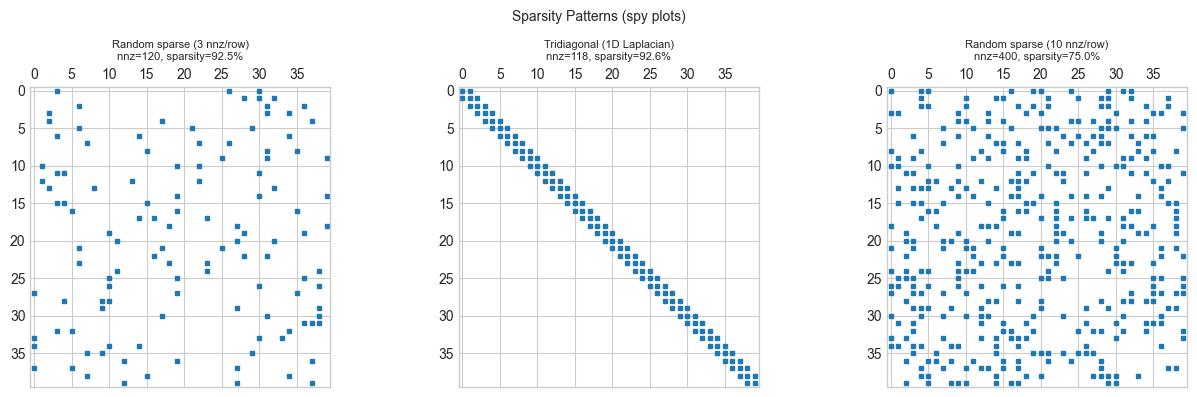

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)

# Visualize sparsity patterns of matrices from different domains
def random_sparse(n, nnz_per_row, rng=rng):
    """Random sparse matrix with fixed nnz per row."""
    rows, cols, vals = [], [], []
    for i in range(n):
        js = rng.choice(n, nnz_per_row, replace=False)
        for j in js:
            rows.append(i)
            cols.append(j)
            vals.append(rng.normal())
    return np.array(rows), np.array(cols), np.array(vals), (n, n)

def tridiagonal_matrix(n):
    """Tridiagonal matrix (finite difference Laplacian)."""
    rows, cols, vals = [], [], []
    for i in range(n):
        rows.append(i); cols.append(i); vals.append(2.0)
        if i > 0:   rows.append(i); cols.append(i-1); vals.append(-1.0)
        if i < n-1: rows.append(i); cols.append(i+1); vals.append(-1.0)
    return np.array(rows), np.array(cols), np.array(vals), (n, n)

def sparse_to_dense(rows, cols, vals, shape):
    A = np.zeros(shape)
    for r, c, v in zip(rows, cols, vals):
        A[r, c] += v
    return A

n_vis = 40
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (rows, cols, vals, shape), title in [
    (axes[0], random_sparse(n_vis, 3),    'Random sparse (3 nnz/row)'),
    (axes[1], tridiagonal_matrix(n_vis),  'Tridiagonal (1D Laplacian)'),
    (axes[2], random_sparse(n_vis, 10),   'Random sparse (10 nnz/row)'),
]:
    A_dense = sparse_to_dense(rows, cols, vals, shape)
    ax.spy(A_dense, markersize=3)
    nnz = len(vals)
    sparsity = 1 - nnz / (n_vis**2)
    ax.set_title(f'{title}\nnnz={nnz}, sparsity={sparsity:.1%}', fontsize=8)

plt.suptitle('Sparsity Patterns (spy plots)', fontsize=10)
plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

**COO format** for $A \in \mathbb{R}^{m \times n}$ with $nnz$ non-zeros:
$$\text{data} = [v_1, \ldots, v_{nnz}], \quad \text{row\_idx} = [r_1, \ldots, r_{nnz}], \quad \text{col\_idx} = [c_1, \ldots, c_{nnz}]$$
Storage: $3 \cdot nnz$ numbers. Access to $A[i,j]$: $O(nnz)$ scan.

**CSR format** adds a row pointer array `indptr` of length $m+1$:
- `indptr[i]` = index in `data`/`col_idx` where row $i$ starts
- `indptr[i+1] - indptr[i]` = number of non-zeros in row $i$

Storage: $2 \cdot nnz + m + 1$ numbers. Row access: $O(1)$. Matrix-vector product:
$$y_i = \sum_{j=\text{indptr}[i]}^{\text{indptr}[i+1]-1} \text{data}[j] \cdot x[\text{col\_idx}[j]]$$
Time: $O(nnz)$ total — one pass through all non-zeros.

## 5. Python Implementation

In [2]:
# --- Sparse Matrix Classes: COO and CSR ---

class SparseMatrixCOO:
    """
    COO (Coordinate) sparse matrix.
    Stores triplets (row, col, val) for each non-zero.
    """
    def __init__(self, rows, cols, vals, shape):
        self.rows  = np.asarray(rows, dtype=int)
        self.cols  = np.asarray(cols, dtype=int)
        self.vals  = np.asarray(vals, dtype=float)
        self.shape = shape
    
    def to_dense(self):
        A = np.zeros(self.shape)
        for r, c, v in zip(self.rows, self.cols, self.vals):
            A[r, c] += v
        return A
    
    def to_csr(self):
        """Convert COO to CSR format."""
        m = self.shape[0]
        # Sort by row
        order  = np.argsort(self.rows)
        rows_s = self.rows[order]
        cols_s = self.cols[order]
        vals_s = self.vals[order]
        
        # Build indptr: counts per row
        indptr = np.zeros(m + 1, dtype=int)
        for r in rows_s:
            indptr[r + 1] += 1
        np.cumsum(indptr, out=indptr)
        
        return SparseMatrixCSR(indptr, cols_s, vals_s, self.shape)
    
    @property
    def nnz(self):
        return len(self.vals)


class SparseMatrixCSR:
    """
    CSR (Compressed Sparse Row) sparse matrix.
    Efficient row access and matrix-vector product.
    """
    def __init__(self, indptr, col_idx, data, shape):
        self.indptr  = np.asarray(indptr,  dtype=int)
        self.col_idx = np.asarray(col_idx, dtype=int)
        self.data    = np.asarray(data,    dtype=float)
        self.shape   = shape
    
    def matvec(self, x):
        """
        Sparse matrix-vector product: y = A @ x
        Time: O(nnz) — one pass through non-zeros.
        """
        m = self.shape[0]
        y = np.zeros(m)
        for i in range(m):
            start, end = self.indptr[i], self.indptr[i+1]
            y[i] = np.dot(self.data[start:end], x[self.col_idx[start:end]])
        return y
    
    def to_dense(self):
        A = np.zeros(self.shape)
        m = self.shape[0]
        for i in range(m):
            for k in range(self.indptr[i], self.indptr[i+1]):
                A[i, self.col_idx[k]] += self.data[k]
        return A
    
    @property
    def nnz(self):
        return len(self.data)

# --- Test ---
rows_t = [0, 0, 1, 2, 2]
cols_t = [0, 2, 1, 0, 2]
vals_t = [1, 2, 3, 4, 5]
shape_t = (3, 3)

coo = SparseMatrixCOO(rows_t, cols_t, vals_t, shape_t)
csr = coo.to_csr()

x_test = np.array([1.0, 2.0, 3.0])
y_sparse = csr.matvec(x_test)
y_dense  = coo.to_dense() @ x_test

print('Dense matrix:')
print(coo.to_dense())
print(f'Sparse matvec: {y_sparse}')
print(f'Dense matvec:  {y_dense}')
print(f'Match: {np.allclose(y_sparse, y_dense)}')

Dense matrix:
[[1. 0. 2.]
 [0. 3. 0.]
 [4. 0. 5.]]
Sparse matvec: [ 7.  6. 19.]
Dense matvec:  [ 7.  6. 19.]
Match: True


## 6. Experiments

In [3]:
# --- Experiment: Sparse vs Dense matvec timing ---
# Hypothesis: sparse matvec is faster when nnz << n^2.
# Try changing: N, NNZ_PER_ROW
import time

N          = 1000   # <-- try 500, 2000
NNZ_PER_ROW = 5     # <-- try 3, 10, 50

# Build sparse matrix
rows_e, cols_e, vals_e = [], [], []
for i in range(N):
    js = rng.choice(N, NNZ_PER_ROW, replace=False)
    for j in js:
        rows_e.append(i); cols_e.append(j); vals_e.append(rng.normal())

coo_e = SparseMatrixCOO(rows_e, cols_e, vals_e, (N, N))
csr_e = coo_e.to_csr()
A_dense_e = coo_e.to_dense()
x_e = rng.normal(0, 1, N)

# Time sparse matvec
N_REPS = 20
t0 = time.perf_counter()
for _ in range(N_REPS):
    y_s = csr_e.matvec(x_e)
t_sparse = (time.perf_counter() - t0) / N_REPS

# Time dense matvec
t0 = time.perf_counter()
for _ in range(N_REPS):
    y_d = A_dense_e @ x_e
t_dense = (time.perf_counter() - t0) / N_REPS

sparsity = 1 - csr_e.nnz / (N**2)
print(f'Matrix: {N}x{N}, {NNZ_PER_ROW} nnz/row')
print(f'Total nnz: {csr_e.nnz}  ({100*(1-sparsity):.2f}% non-zero)')
print(f'Sparse matvec: {t_sparse*1000:.3f} ms')
print(f'Dense matvec:  {t_dense*1000:.3f} ms')
print(f'Speedup: {t_dense/t_sparse:.1f}x')
print(f'Results match: {np.allclose(y_s, y_d)}')

Matrix: 1000x1000, 5 nnz/row
Total nnz: 5000  (0.50% non-zero)
Sparse matvec: 3.362 ms
Dense matvec:  0.471 ms
Speedup: 0.1x
Results match: True


## 7. Exercises

**Easy 1.** For a $100 \times 100$ tridiagonal matrix (3 nnz per row), compute: total elements, nnz, sparsity fraction, memory ratio (sparse COO vs dense).

**Easy 2.** Implement `SparseMatrixCSR.transpose()` that returns a new CSR matrix representing $A^\top$ without converting to dense.

**Medium 1.** Implement sparse matrix addition in CSR format: given two CSR matrices $A$ and $B$ with the same shape, compute $C = A + B$ in CSR format.

**Medium 2.** The **power method** for finding the dominant eigenvector *(ch171)* only uses matrix-vector products. Implement it using `SparseMatrixCSR.matvec` and apply it to a large sparse graph Laplacian to find the Fiedler vector *(ch191)*.

**Hard.** Implement the **conjugate gradient method** for solving $A\mathbf{x} = \mathbf{b}$ when $A$ is symmetric positive definite and sparse. Each iteration uses only one sparse matvec. Compare convergence rate to dense Gaussian elimination on a 1D Laplacian system of size $n = 1000$.

## 8. Mini Project

PageRank scores (top 10 pages):
  Rank 1: Page 24  score=0.0748
  Rank 2: Page 3  score=0.0690
  Rank 3: Page 15  score=0.0645
  Rank 4: Page 29  score=0.0634
  Rank 5: Page 21  score=0.0472
  Rank 6: Page 23  score=0.0423
  Rank 7: Page 12  score=0.0375
  Rank 8: Page 26  score=0.0367
  Rank 9: Page 25  score=0.0284
  Rank 10: Page 11  score=0.0283


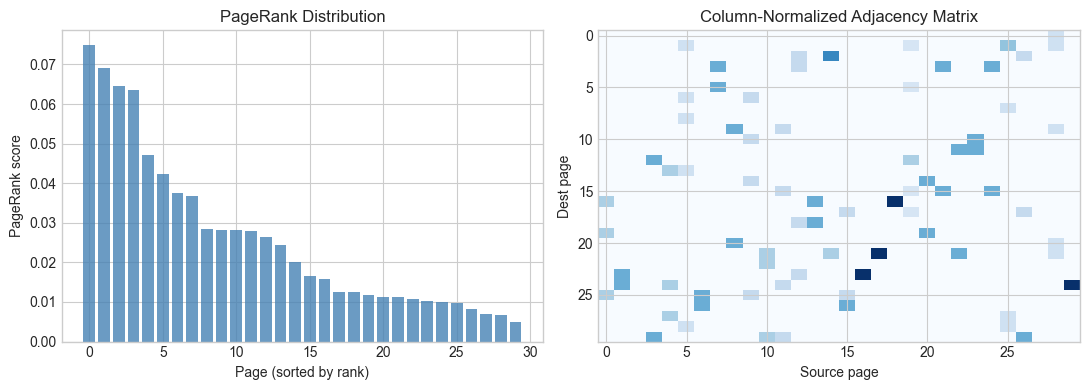

In [4]:
# --- Mini Project: PageRank via Sparse Matrix-Vector Products ---
# Problem: Compute PageRank scores for a web graph using the power method on a sparse matrix.
# PageRank: r = d * A_norm @ r + (1-d)/n * ones
# where A_norm is the column-normalized adjacency matrix.

n_pages  = 30
N_LINKS  = 80   # total directed edges
DAMPING  = 0.85

# Random web graph
src = rng.integers(0, n_pages, N_LINKS)
dst = rng.integers(0, n_pages, N_LINKS)
# Remove self-loops
mask = src != dst
src, dst = src[mask], dst[mask]

# Build column-normalized adjacency (each column sums to 1)
A_pr = np.zeros((n_pages, n_pages))
for s, d in zip(src, dst):
    A_pr[d, s] += 1.0   # column s is source, row d is destination

# Normalize columns
col_sums = A_pr.sum(axis=0)
col_sums[col_sums == 0] = 1   # dangling nodes
A_pr /= col_sums[None, :]

# Power iteration for PageRank
r = np.ones(n_pages) / n_pages
for _ in range(100):
    r_new = DAMPING * A_pr @ r + (1 - DAMPING) / n_pages * np.ones(n_pages)
    if np.linalg.norm(r_new - r) < 1e-10:
        break
    r = r_new

print('PageRank scores (top 10 pages):')
top_pages = np.argsort(r)[::-1][:10]
for rank_i, page_i in enumerate(top_pages):
    print(f'  Rank {rank_i+1}: Page {page_i}  score={r[page_i]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(range(n_pages), r[np.argsort(r)[::-1]], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Page (sorted by rank)')
axes[0].set_ylabel('PageRank score')
axes[0].set_title('PageRank Distribution')
axes[1].imshow(A_pr, cmap='Blues', aspect='auto')
axes[1].set_title('Column-Normalized Adjacency Matrix')
axes[1].set_xlabel('Source page')
axes[1].set_ylabel('Dest page')
plt.tight_layout()
plt.show()

## 9. Chapter Summary & Connections

- Sparse matrices store only non-zero entries: COO format stores (row, col, val) triples; CSR stores sorted rows with a pointer array for $O(1)$ row access and $O(nnz)$ matrix-vector products.
- Sparsity arises structurally in graphs, physics simulations, and text data — where interaction is local or categorical.
- The speedup from sparse matvec scales with sparsity: for $nnz \ll mn$, computation is orders of magnitude faster than dense.
- PageRank, graph spectral methods *(ch191)*, and iterative solvers all use sparse matrix-vector products as their core operation.

**Forward:** Sparse representations underlie nearly all large-scale linear algebra used in ch191 (Graph Embedding) and ch271–300 (Part IX — Data Science). Gradient computation in deep learning uses sparse Jacobians implicitly. The conjugate gradient method from the Hard exercise is the standard solver for large sparse symmetric positive definite systems encountered in physics and engineering.

**Backward:** The sparsity pattern of the graph Laplacian *(ch191)* and the adjacency matrix *(ch151)* is exactly what makes spectral graph methods computationally feasible at scale.